In [69]:

from __future__ import annotations

import os
import re
from collections import Counter
from dataclasses import dataclass
from typing import Literal
from typing_extensions import TypedDict

from IPython.display import Markdown, display
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI


In [70]:
class EducationState(TypedDict, total=False):
    learner_name: str
    topic: str
    material: str
    focus_mode: Literal["vocab", "sentence"]

    cleaned_material: str
    keywords: list[str]
    summary: str

    examples: list[str]
    focus_plan: dict[str, list[str]]
    preread_note: str
    memory_log: list[str]

    # LLM이 생성한 구조화 항목
    # vocab_items: [{term, meaning, context_example}]
    # sentence_items: [{source_sentence, structure_breakdown, why_difficult}]
    vocab_items: list[dict]
    sentence_items: list[dict]
    preference_info: dict[str, object]


In [71]:

@dataclass
class ExampleBankTool:
    '''간단한 커스텀 툴: 주제별 예문/패턴을 반환.'''

    mini_db: dict[str, list[str]]

    def __call__(self, topic: str, focus_mode: str, keywords: list[str]) -> list[str]:
        pool = self.mini_db.get(topic.lower(), self.mini_db.get("default", []))
        highlight = {k.lower() for k in keywords[:2]}
        filtered = [s for s in pool if any(word in s.lower() for word in highlight)]
        return filtered or pool


def create_example_tool() -> ExampleBankTool:
    return ExampleBankTool(
        mini_db={
            "ai": [
                "Transformers rely on self-attention to capture sentence-level context.",
                "Reinforcement learning tunes policies by rewarding strategic choices.",
                "Vector databases keep embeddings searchable for retrieval-augmented generation.",
            ],
            "productivity": [
                "Batching similar tasks reduces cognitive switching costs.",
                "A stand-up meeting enforces concise sentence-level reporting.",
                "Vocabulary journals make deliberate practice measurable.",
            ],
            "default": [
                "Preview the bold vocabulary before reading the full passage.",
                "Underline long sentences and restate them with simpler syntax.",
                "Relate new ideas to prior knowledge to speed up recall.",
            ],
        }
    )


example_tool = create_example_tool()


In [72]:
# ── 선호도 가중치 ────────────────────────────────────────────────────────────
# 12.5 선호도에 따른 예습노트 비율
#   vocab    : 단어/표현 70 / 문장 30
#   sentence : 단어/표현 40 / 문장 60

PREFERENCE_WEIGHTS: dict[str, dict[str, float]] = {
    "vocab":    {"vocab_ratio": 0.7, "sentence_ratio": 0.3},
    "sentence": {"vocab_ratio": 0.4, "sentence_ratio": 0.6},
}

TOTAL_ITEMS = 10  # vocab + sentence 합산 목표 항목 수


# ── LLM 프롬프트 ─────────────────────────────────────────────────────────────

_LLM_SYSTEM = "당신은 외국어 원서 예습을 돕는 전문 언어 교사입니다."

_VOCAB_USER_TEMPLATE = """\
다음 원문에서 핵심 단어/표현 {n}개를 추출하고 한국어로 풀이하세요.
주제: {topic}

[원문]
{text}

반드시 JSON 배열만 응답하세요 (다른 텍스트, 마크다운 코드블록 없이):
[
  {{
    "term": "단어 또는 표현 (영어)",
    "meaning": "문맥 속 한국어 의미 (1-2문장)",
    "context_example": "원문에서 발췌하거나 유사한 예문 (영어)"
  }}
]"""

_SENTENCE_USER_TEMPLATE = """\
다음 원문에서 학습 가치가 높은 문장 {n}개를 선택하고 한국어로 구조 해설하세요.

[원문]
{text}

반드시 JSON 배열만 응답하세요 (다른 텍스트, 마크다운 코드블록 없이):
[
  {{
    "source_sentence": "원문 문장 그대로",
    "structure_breakdown": "주어/동사/목적어/절 구조를 한국어로 해설",
    "why_difficult": "이 문장이 학습자에게 어려운 이유 (한국어, 1-2줄)"
  }}
]"""


# ── PreReadNoteLLM ────────────────────────────────────────────────────────────

class PreReadNoteLLM:
    """백엔드 generate_preread_note_node 참고.
    단일 LLM 호출로 vocab 항목 또는 sentence 항목을 JSON 배열로 생성한다.
    OPENAI_API_KEY 없으면 fallback 플레이스홀더를 반환한다.
    """

    MAX_TEXT = 6_000

    def __init__(self) -> None:
        api_key = os.getenv("OPENAI_API_KEY")
        model = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
        self.client: ChatOpenAI | None = None
        if api_key:
            try:
                self.client = ChatOpenAI(model=model, temperature=0.2)
            except Exception as exc:
                print(f"[WARN] ChatOpenAI 초기화 실패: {exc}")

    def _call(self, user_prompt: str) -> str | None:
        if not self.client:
            return None
        try:
            resp = self.client.invoke(
                [SystemMessage(content=_LLM_SYSTEM), HumanMessage(content=user_prompt)]
            )
            content = resp.content
            if isinstance(content, list):
                return " ".join(p.get("text", "") for p in content if isinstance(p, dict))
            return str(content)
        except Exception as exc:
            print(f"[WARN] LLM 호출 실패: {exc}")
            return None

    def _parse_json_array(self, raw: str) -> list[dict] | None:
        """LLM 응답에서 JSON 배열을 파싱한다."""
        try:
            match = re.search(r"\[[\s\S]+\]", raw)
            if match:
                return json.loads(match.group())
        except Exception:
            pass
        return None

    # ── 공개 메서드 ──────────────────────────────────────────────────────────

    def generate_vocab_items(self, topic: str, text: str, n: int) -> list[dict]:
        """단어/표현 항목을 n개 생성한다. 각 항목: term / meaning / context_example"""
        prompt = _VOCAB_USER_TEMPLATE.format(n=n, topic=topic, text=text[: self.MAX_TEXT])
        raw = self._call(prompt)
        if raw:
            items = self._parse_json_array(raw)
            if items:
                return items[:n]
        # Fallback: 키워드 기반 플레이스홀더
        kws = _extract_keywords(text, n)
        return [
            {
                "term": w,
                "meaning": f"'{w}'의 '{topic}' 맥락 의미를 한국어로 정리하세요.",
                "context_example": f"(원문에서 '{w}' 사용 예문을 찾으세요)",
            }
            for w in kws
        ]

    def generate_sentence_items(self, text: str, n: int) -> list[dict]:
        """문장 구조 해설 항목을 n개 생성한다. 각 항목: source_sentence / structure_breakdown / why_difficult"""
        prompt = _SENTENCE_USER_TEMPLATE.format(n=n, text=text[: self.MAX_TEXT])
        raw = self._call(prompt)
        if raw:
            items = self._parse_json_array(raw)
            if items:
                return items[:n]
        # Fallback: 원문 문장 분리
        sentences = [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()][:n]
        return [
            {
                "source_sentence": s,
                "structure_breakdown": "문장 구조(주어/동사/목적어/부사절)를 한국어로 분석하세요.",
                "why_difficult": "",
            }
            for s in sentences
        ]


preread_llm = PreReadNoteLLM()
print(f"[INFO] LLM 사용 가능: {preread_llm.client is not None}")


[INFO] LLM 사용 가능: True


In [73]:
import json


def _extract_keywords(text: str, top_k: int = 5) -> list[str]:
    tokens = re.findall(r"[a-zA-Z']+", text.lower())
    tokens = [t for t in tokens if len(t) >= 5]
    counts = Counter(tokens)
    return [word.title() for word, _ in counts.most_common(top_k)]


def _summarize(text: str, max_sentences: int = 2) -> str:
    sentences = re.split(r"(?<=[.!?])\s+", text.strip())
    sentences = [s.strip() for s in sentences if s.strip()]
    return " ".join(sentences[:max_sentences])


def _update_memory(state: EducationState, message: str) -> list[str]:
    return [*state.get("memory_log", []), message]


In [74]:
def ingest_material_node(state: EducationState) -> dict:
    cleaned = " ".join(state["material"].split())
    return {
        "cleaned_material": cleaned,
        "memory_log": _update_memory(state, "ingest_material: 원문 정제 완료"),
    }


def analyze_material_node(state: EducationState) -> dict:
    text = state.get("cleaned_material", state["material"])
    keywords = _extract_keywords(text)
    summary = _summarize(text)
    return {
        "keywords": keywords,
        "summary": summary,
        "memory_log": _update_memory(state, f"analyze_material: 키워드 {keywords} / 요약 생성"),
    }


def vocab_focus_node(state: EducationState) -> dict:
    """어휘 중심 경로: ExampleBankTool로 예문을 수집하고 어휘 학습 플랜을 수립한다."""
    examples = example_tool(state["topic"], state["focus_mode"], state.get("keywords", []))
    plan = {
        "steps": [
            "핵심 단어/표현의 CEFR 수준과 발음을 확인하세요.",
            "각 단어로 개인 예문을 직접 작성하세요.",
            "단어가 원문에서 어떤 맥락으로 쓰였는지 찾아보세요.",
        ],
        "keywords": state.get("keywords", []),
    }
    return {
        "examples": examples,
        "focus_plan": plan,
        "memory_log": _update_memory(state, "vocab_focus: 어휘 플랜 + ExampleBankTool 호출"),
    }


def sentence_focus_node(state: EducationState) -> dict:
    """문장 중심 경로: ExampleBankTool로 예문을 수집하고 문장 구조 학습 플랜을 수립한다."""
    examples = example_tool(state["topic"], state["focus_mode"], state.get("keywords", []))
    plan = {
        "steps": [
            "긴 문장을 절 단위로 나누어 각 절의 역할을 파악하세요.",
            "접속사·관계사·분사구문 등 연결 장치를 표시하세요.",
            "복잡한 문장을 짧은 문장 2-3개로 패러프레이즈 연습하세요.",
        ],
        "keywords": state.get("keywords", []),
    }
    return {
        "examples": examples,
        "focus_plan": plan,
        "memory_log": _update_memory(state, "sentence_focus: 문장 플랜 + ExampleBankTool 호출"),
    }


def assemble_note_node(state: EducationState) -> dict:
    """선호도 비율에 따라 LLM으로 단어/표현 항목과 문장 구조 해설을 생성하고 예습노트를 조립한다.

    선호도 규칙 (12.5):
        vocab    → 단어/표현 70%, 문장 30%
        sentence → 단어/표현 40%, 문장 60%
    """
    text = state.get("cleaned_material", state.get("material", ""))
    mode = state.get("focus_mode", "vocab")
    topic = state.get("topic", "학습")
    weights = PREFERENCE_WEIGHTS[mode]

    # 항목 수 결정
    vocab_count = round(TOTAL_ITEMS * weights["vocab_ratio"])
    sentence_count = TOTAL_ITEMS - vocab_count

    # LLM 단일 호출 × 2 (vocab 배치 / sentence 배치)
    vocab_items = preread_llm.generate_vocab_items(topic, text, vocab_count)
    sentence_items = preread_llm.generate_sentence_items(text, sentence_count)

    plan_steps = state.get("focus_plan", {}).get("steps", [])
    examples = state.get("examples", [])

    # ── 예습노트 포매팅 ──────────────────────────────────────────────────────
    vocab_lines: list[str] = []
    for i, item in enumerate(vocab_items, 1):
        vocab_lines += [
            f"  {i}. **{item['term']}**",
            f"     - 의미: {item['meaning']}",
            f"     - 예문: {item.get('context_example', '')}",
        ]

    sentence_lines: list[str] = []
    for i, item in enumerate(sentence_items, 1):
        sentence_lines += [
            f"  {i}. 원문: _{item['source_sentence']}_",
            f"     - 구조 해설: {item['structure_breakdown']}",
        ]
        if item.get("why_difficult"):
            sentence_lines.append(f"     - 어려운 이유: {item['why_difficult']}")

    note_lines = [
        "# 예습노트",
        f"학습자: {state.get('learner_name', 'N/A')} | 주제: {topic} | 모드: {mode}",
        f"적용 비율 — 단어/표현: {int(weights['vocab_ratio'] * 100)}% / 문장: {int(weights['sentence_ratio'] * 100)}%",
        "",
        "## 요약",
        state.get("summary", ""),
        "",
        f"## 단어/표현 정리 ({vocab_count}개) — 한국어 풀이",
        *vocab_lines,
        "",
        f"## 문장 구조 해설 ({sentence_count}개) — 한국어 해설",
        *sentence_lines,
        "",
        "## 예습 액션 플랜",
        *(f"- {step}" for step in plan_steps),
        "",
        "## 참고 예문 (ExampleBankTool)",
        *(f"- {ex}" for ex in examples),
    ]

    return {
        "preread_note": "\n".join(note_lines),
        "memory_log": _update_memory(state, "assemble_note: 선호도 기반 예습노트 완성"),
        "vocab_items": vocab_items,
        "sentence_items": sentence_items,
        "preference_info": {
            "input_mode": mode,
            "vocab_count": vocab_count,
            "sentence_count": sentence_count,
            "vocab_ratio": weights["vocab_ratio"],
            "sentence_ratio": weights["sentence_ratio"],
        },
    }


def route_focus(state: EducationState) -> str:
    """Conditional edge: focus_mode에 따라 vocab_focus 또는 sentence_focus로 분기."""
    return "sentence" if state.get("focus_mode") == "sentence" else "vocab"


In [75]:

graph_builder = StateGraph(EducationState)

graph_builder.add_node("ingest_material", ingest_material_node)
graph_builder.add_node("analyze_material", analyze_material_node)
graph_builder.add_node("vocab_focus", vocab_focus_node)
graph_builder.add_node("sentence_focus", sentence_focus_node)
graph_builder.add_node("assemble_note", assemble_note_node)

graph_builder.set_entry_point("ingest_material")

graph_builder.add_edge("ingest_material", "analyze_material")

graph_builder.add_conditional_edges(
    "analyze_material",
    route_focus,
    {
        "vocab": "vocab_focus",
        "sentence": "sentence_focus",
    },
)

graph_builder.add_edge("vocab_focus", "assemble_note")
graph_builder.add_edge("sentence_focus", "assemble_note")
graph_builder.add_edge("assemble_note", END)


education_agent = graph_builder.compile()


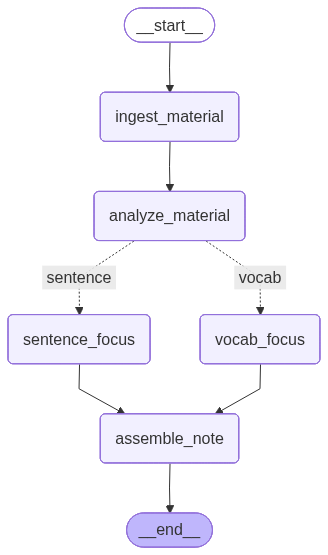

In [76]:
education_agent

In [77]:
SAMPLE_MATERIAL = (
    "When teams looked sluggish at the Tuesday stand-up, I tried an experiment. "
    "Each contributor wrote a micro-brief covering yesterday's decisions, today's priority, "
    "and one risk blocking momentum. The reports were short enough to skim but detailed enough "
    "to expose hidden context debt, so by Thursday we trimmed meetings and surfaced conflicts early."
)

# ── vocab 모드 (단어/표현 70%, 문장 30%) ─────────────────────────────────────
result_vocab = education_agent.invoke({
    "learner_name": "Alice",
    "topic": "productivity",
    "focus_mode": "vocab",
    "material": SAMPLE_MATERIAL,
    "memory_log": [],
})

# ── sentence 모드 (단어/표현 40%, 문장 60%) ──────────────────────────────────
result_sentence = education_agent.invoke({
    "learner_name": "Bob",
    "topic": "productivity",
    "focus_mode": "sentence",
    "material": SAMPLE_MATERIAL,
    "memory_log": [],
})

print("두 가지 모드 실행 완료.")


두 가지 모드 실행 완료.


In [78]:
def show_result(result: dict, label: str) -> None:
    pref = result["preference_info"]
    print(f"\n{'='*60}")
    print(f"[{label}] 모드={pref['input_mode']} | "
          f"단어 {pref['vocab_count']}개 / 문장 {pref['sentence_count']}개 "
          f"({int(pref['vocab_ratio']*100)}:{int(pref['sentence_ratio']*100)})")
    print("-" * 60)
    print("[메모리 로그]")
    for item in result["memory_log"]:
        print(" ", item)
    print()
    display(Markdown(result["preread_note"]))


show_result(result_vocab, "vocab 모드")
show_result(result_sentence, "sentence 모드")



[vocab 모드] 모드=vocab | 단어 7개 / 문장 3개 (70:30)
------------------------------------------------------------
[메모리 로그]
  ingest_material: 원문 정제 완료
  analyze_material: 키워드 ['Enough', 'Teams', 'Looked', 'Sluggish', 'Tuesday'] / 요약 생성
  vocab_focus: 어휘 플랜 + ExampleBankTool 호출
  assemble_note: 선호도 기반 예습노트 완성



# 예습노트
학습자: Alice | 주제: productivity | 모드: vocab
적용 비율 — 단어/표현: 70% / 문장: 30%

## 요약
When teams looked sluggish at the Tuesday stand-up, I tried an experiment. Each contributor wrote a micro-brief covering yesterday's decisions, today's priority, and one risk blocking momentum.

## 단어/표현 정리 (7개) — 한국어 풀이
  1. **sluggish**
     - 의미: 느리거나 비활동적인 상태를 의미하며, 팀의 생산성이 떨어진 상황을 나타냅니다.
     - 예문: When teams looked sluggish at the Tuesday stand-up
  2. **experiment**
     - 의미: 어떤 결과를 얻기 위해 시도하는 새로운 방법이나 절차를 의미합니다.
     - 예문: I tried an experiment.
  3. **micro-brief**
     - 의미: 짧고 간결한 보고서를 의미하며, 핵심 정보를 빠르게 전달하는 데 초점을 맞춥니다.
     - 예문: Each contributor wrote a micro-brief covering yesterday's decisions
  4. **priority**
     - 의미: 우선순위를 의미하며, 가장 중요한 일이나 과제를 나타냅니다.
     - 예문: today's priority
  5. **risk**
     - 의미: 위험 요소를 의미하며, 진행 중인 작업에 방해가 될 수 있는 요소를 나타냅니다.
     - 예문: one risk blocking momentum
  6. **context debt**
     - 의미: 상황이나 배경에 대한 정보 부족을 의미하며, 팀의 의사소통에서 발생할 수 있는 문제를 나타냅니다.
     - 예문: to expose hidden context debt
  7. **trimmed meetings**
     - 의미: 회의 시간을 줄이거나 간소화하는 것을 의미하며, 효율성을 높이기 위한 조치를 나타냅니다.
     - 예문: by Thursday we trimmed meetings

## 문장 구조 해설 (3개) — 한국어 해설
  1. 원문: _When teams looked sluggish at the Tuesday stand-up, I tried an experiment._
     - 구조 해설: 주어(teams) + 동사(looked) + 보어(sluggish) + 부사구(at the Tuesday stand-up) + 주어(I) + 동사(tried) + 목적어(an experiment)
     - 어려운 이유: 복잡한 시간 부사절이 포함되어 있어 문장의 전체 의미를 이해하기 어려울 수 있다.
  2. 원문: _Each contributor wrote a micro-brief covering yesterday's decisions, today's priority, and one risk blocking momentum._
     - 구조 해설: 주어(Each contributor) + 동사(wrote) + 목적어(a micro-brief) + 현재분사구(covering yesterday's decisions, today's priority, and one risk blocking momentum)
     - 어려운 이유: 현재분사구가 여러 개의 요소를 나열하고 있어 문장이 길고 복잡하게 느껴질 수 있다.
  3. 원문: _The reports were short enough to skim but detailed enough to expose hidden context debt, so by Thursday we trimmed meetings and surfaced conflicts early._
     - 구조 해설: 주어(The reports) + 동사(were) + 보어(short enough to skim but detailed enough to expose hidden context debt) + 접속사(so) + 주어(we) + 동사(trimmed, surfaced) + 목적어(meetings, conflicts) + 부사구(early)
     - 어려운 이유: 복합적인 구조와 여러 개의 형용사구가 포함되어 있어 문장의 의미를 파악하기 어려울 수 있다.

## 예습 액션 플랜
- 핵심 단어/표현의 CEFR 수준과 발음을 확인하세요.
- 각 단어로 개인 예문을 직접 작성하세요.
- 단어가 원문에서 어떤 맥락으로 쓰였는지 찾아보세요.

## 참고 예문 (ExampleBankTool)
- Batching similar tasks reduces cognitive switching costs.
- A stand-up meeting enforces concise sentence-level reporting.
- Vocabulary journals make deliberate practice measurable.


[sentence 모드] 모드=sentence | 단어 4개 / 문장 6개 (40:60)
------------------------------------------------------------
[메모리 로그]
  ingest_material: 원문 정제 완료
  analyze_material: 키워드 ['Enough', 'Teams', 'Looked', 'Sluggish', 'Tuesday'] / 요약 생성
  sentence_focus: 문장 플랜 + ExampleBankTool 호출
  assemble_note: 선호도 기반 예습노트 완성



# 예습노트
학습자: Bob | 주제: productivity | 모드: sentence
적용 비율 — 단어/표현: 40% / 문장: 60%

## 요약
When teams looked sluggish at the Tuesday stand-up, I tried an experiment. Each contributor wrote a micro-brief covering yesterday's decisions, today's priority, and one risk blocking momentum.

## 단어/표현 정리 (4개) — 한국어 풀이
  1. **micro-brief**
     - 의미: 짧고 간결한 보고서로, 핵심 정보를 빠르게 전달하는 데 초점을 맞춘다.
     - 예문: Each contributor wrote a micro-brief covering yesterday's decisions, today's priority, and one risk blocking momentum.
  2. **context debt**
     - 의미: 상황이나 배경에 대한 정보가 부족해 발생하는 문제로, 팀의 의사소통에 장애가 될 수 있다.
     - 예문: detailed enough to expose hidden context debt
  3. **trimmed meetings**
     - 의미: 회의의 시간을 줄이거나 불필요한 부분을 제거하여 효율성을 높이는 것을 의미한다.
     - 예문: by Thursday we trimmed meetings
  4. **surfaced conflicts**
     - 의미: 팀 내에서 발생하는 갈등이나 문제를 조기에 드러내어 해결하는 과정을 나타낸다.
     - 예문: and surfaced conflicts early.

## 문장 구조 해설 (6개) — 한국어 해설
  1. 원문: _When teams looked sluggish at the Tuesday stand-up, I tried an experiment._
     - 구조 해설: 주어(teams) + 동사(looked) + 보어(sluggish) + 부사구(at the Tuesday stand-up) / 주어(I) + 동사(tried) + 목적어(an experiment)
     - 어려운 이유: 복잡한 시간 부사절이 포함되어 있어 문장의 전체 의미를 이해하기 어려울 수 있습니다.
  2. 원문: _Each contributor wrote a micro-brief covering yesterday's decisions, today's priority, and one risk blocking momentum._
     - 구조 해설: 주어(Each contributor) + 동사(wrote) + 목적어(a micro-brief) + 현재분사구(covering yesterday's decisions, today's priority, and one risk blocking momentum)
     - 어려운 이유: 현재분사구가 여러 개 포함되어 있어 문장이 길고 복잡하게 느껴질 수 있습니다.
  3. 원문: _The reports were short enough to skim but detailed enough to expose hidden context debt._
     - 구조 해설: 주어(The reports) + 동사(were) + 보어(short enough to skim) + 접속사(but) + 보어(detailed enough to expose hidden context debt)
     - 어려운 이유: 두 개의 보어가 대조적으로 연결되어 있어 의미를 파악하기 어려울 수 있습니다.
  4. 원문: _so by Thursday we trimmed meetings and surfaced conflicts early._
     - 구조 해설: 부사구(so by Thursday) + 주어(we) + 동사(trimmed) + 목적어(meetings) + 접속사(and) + 동사(surfaced) + 목적어(conflicts) + 부사(early)
     - 어려운 이유: 문장의 흐름이 빠르게 진행되어서 주어와 동사의 관계를 놓치기 쉬울 수 있습니다.
  5. 원문: _Each contributor wrote a micro-brief covering yesterday's decisions, today's priority, and one risk blocking momentum._
     - 구조 해설: 주어(Each contributor) + 동사(wrote) + 목적어(a micro-brief) + 현재분사구(covering yesterday's decisions, today's priority, and one risk blocking momentum)
     - 어려운 이유: 여러 요소가 나열되어 있어 문장의 구조를 이해하는 데 어려움이 있을 수 있습니다.
  6. 원문: _The reports were short enough to skim but detailed enough to expose hidden context debt._
     - 구조 해설: 주어(The reports) + 동사(were) + 보어(short enough to skim) + 접속사(but) + 보어(detailed enough to expose hidden context debt)
     - 어려운 이유: 상반된 두 가지 특성을 설명하고 있어 혼란을 줄 수 있습니다.

## 예습 액션 플랜
- 긴 문장을 절 단위로 나누어 각 절의 역할을 파악하세요.
- 접속사·관계사·분사구문 등 연결 장치를 표시하세요.
- 복잡한 문장을 짧은 문장 2-3개로 패러프레이즈 연습하세요.

## 참고 예문 (ExampleBankTool)
- Batching similar tasks reduces cognitive switching costs.
- A stand-up meeting enforces concise sentence-level reporting.
- Vocabulary journals make deliberate practice measurable.